In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
from jax.config import config as jax_config
jax_config.update("jax_enable_x64", True)
jax_config.update('jax_disable_jit', False)
import jax.numpy as jnp
import objax

import stgp as lego
from stgp import settings
from stgp.trainers import ScipyTrainer, NatGradTrainer, GradDescentTrainer
from stgp.trainers.callbacks import progress_bar_callback
from stgp.kernels import Matern32
from stgp.likelihood import Gaussian, ReshapedGaussian
from stgp.data import TemporalData, Data
from stgp.models import GP
from stgp.sparsity import NoSparsity
from stgp.transforms import Independent
from stgp.transforms.sdes import LTI_SDE
from stgp.approximate_posteriors import MeanFieldApproximatePosterior , MeanFieldConjugateGaussian, ConjugateGaussian, FullConjugateGaussian


import matplotlib.pyplot as plt

import numpy as np

from data_zoo import single_output_timeseries


# Introduction


In the regression setting a variational GP can recover the standard GP in a single natural gradient step. Here we show this empirically. 

# Timeseries setting

In [3]:
# Fix randomness
np.random.seed(0)

XS, X, Y = single_output_timeseries(100, 1000, seed=0)

config = {
    'ls': 0.5,
    'lik_var': 0.01,
    'epochs': 10,
    'lr': 0.01
}

res_time = {}

## Batch GP

In [4]:
def timeseries_batch_gp(config, XS, X, Y):
    data = Data(X, Y)
    kernel = Matern32(lengthscales=[config['ls']])
    lik = Gaussian(variance=config['lik_var'])
    
    m = GP(
        data = data,
        kernel=kernel,
        likelihood=lik,
        inference='Batch'
    )
    
    print(objax.Grad(m.get_objective, m.vars())())
    
    learning_curve, training_time = GradDescentTrainer(
        m, 
        objax.optimizer.Adam
    ).train(
        config['lr'],
        config['epochs'],
        callback = None
    )
    
    pred_mu, pred_var = m.predict_y(XS)
    
    print('pred_var: ', np.sum(pred_var))
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['batch'] = timeseries_batch_gp(config, XS, X, Y)

/Users/ohamelijnck/Documents/projects/stgp/stgp/defaults.py:28: UserWarning: Using default Independent prior
  warnings.warn('Using default Independent prior')


[DeviceArray(3.76875461, dtype=float64, weak_type=True), DeviceArray([29.20187455], dtype=float64)]
pred_var:  433.25663598718234


## State-space GP

In [6]:
def timeseries_sde_gp(config, XS, X, Y):
    data = TemporalData(X=X, Y=Y, sort=True)
    
    kernel = Matern32(lengthscales=[config['ls']])
    
    lik = ReshapedGaussian(Gaussian(variance=config['lik_var']), num_blocks=data.Nt, block_size=data.Ns)
    
    m = GP(
        data = data,
        kernel=kernel,
        likelihood=lik,
        inference='Sequential'
    )
    
    print(m.get_objective())
    
    learning_curve, training_time = GradDescentTrainer(
        m, 
        objax.optimizer.Adam
    ).train(
        config['lr'],
        config['epochs'],
        callback = None
    )
    
    pred_mu, pred_var = m.predict_y(XS)

    print('pred_var: ', np.sum(pred_var))

    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}
    
res_time['sde'] = timeseries_sde_gp(config, XS, X, Y)

ValueError: All input arrays must have the same shape.

## Variational GP

In [7]:
def vi_timeseries_gp(config, XS, X, Y):
    settings.ng_jitter = 1e-7
    
    data = Data(X, Y)
    sparsity = NoSparsity(Z_ref=data._X)
    
    kernel = Matern32(lengthscales=[config['ls']])
    prior = Independent([GP(sparsity=sparsity, kernel=kernel)])
    lik = Gaussian(variance=config['lik_var'])
    
    m = GP(
        data = data,
        prior = prior,
        likelihood = [lik],
        inference = 'Variational'
    )
    
    print(objax.Grad(m.get_objective, m.vars())())
    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    # Do not use adam for the approx posterios
    all_vars = list(m.vars().keys())
    m_name = [a for a in all_vars if a.endswith('._m(Parameter).raw_var')]
    s_chol_name = [a for a in all_vars if a.endswith('._S_chol(Parameter).raw_var')]
    approx_posterior_vars = m_name + s_chol_name
            
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam, hold_vars = approx_posterior_vars)
    
    learning_curve = []
    for i in range(config['epochs']):
        try:
            obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
            grad_step.train(config['lr'], epochs=1)
            learning_curve.append(obj_val[0])
        except Exception as e:
            print(f'Exiting at {i}')
            break
    
    pred_mu, pred_var = m.predict_y(XS)
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}

res_time['vi'] = vi_timeseries_gp(config, XS, X, Y)

/Users/ohamelijnck/Documents/projects/stgp/stgp/approximate_posteriors/gaussian_approximate_posterior.py:21: UserWarning: Approximate posterior 
  warnings.warn('Approximate posterior ')


[DeviceArray(-2944.75891703, dtype=float64, weak_type=True), DeviceArray([159209.3869578], dtype=float64), DeviceArray([[ -16.56689614],
             [ -13.14936889],
             [ -28.86043631],
             [ -51.24704146],
             [ -56.98847717],
             [ -37.61243937],
             [ -65.46425534],
             [ -62.44728661],
             [ -70.26397706],
             [ -82.00044393],
             [ -85.12890478],
             [-103.1618677 ],
             [-100.24656227],
             [ -96.91542496],
             [-102.21401409],
             [-102.18187849],
             [-113.83782043],
             [ -95.87895354],
             [ -99.08618446],
             [ -84.45112027],
             [ -63.54055898],
             [ -90.76681027],
             [ -87.16628021],
             [ -64.58088532],
             [ -87.43648343],
             [ -42.26151429],
             [ -48.73970195],
             [ -37.38482309],
             [ -45.14860642],
             [ -34.7643

## CVI with Batch surrogate GP

In [8]:
def cvi_t_batch_gp(config, XS, X, Y):
    settings.ng_jitter = 1e-7
    
    Q = 1
    
    data = Data(X=X, Y=Y)
    sparsity = [NoSparsity(Z_ref=data._X)]
    
    kernel = Matern32(lengthscales=[config['ls']])
    latent_gps = [GP(sparsity=sparsity[0], kernel=kernel)]
    lik = Gaussian(variance=config['lik_var'])
    
    approx_posterior = MeanFieldConjugateGaussian([
        ConjugateGaussian(
            X=sparsity[q],
            block_size=1,
            surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
                data=Data(X=X.raw_Z, Y=Y[..., 0]), # extra dimension to handle blocks 
                prior=Independent([latent_gps[q]]), 
                likelihood=likelihood[0],
                inference='Batch'
            )  
        )
        for q in range(Q)
    ])
    
    m = GP(
        data = data,
        prior = Independent(latent_gps),
        likelihood = [lik],
        approximate_posterior=approx_posterior,
        inference = 'Variational'
    )

    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    # when using a step size of 1.0 we dont need to remove params from adam
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam)
    
    learning_curve = []
    for i in range(config['epochs']):
        obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
        grad_step.train(config['lr'], epochs=1)
        #learning_curve.append(0.0)
        learning_curve.append(obj_val[0])
        

    pred_mu, pred_var = m.predict_y(XS)
    
    m.print()
    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}

res_time['cvi_t_batch'] = cvi_t_batch_gp(config, XS, X, Y)

Y - 5: {'var': (100, 1)}
X - 5: {'var': (100, 1)}
Gaussian/variance - 5: {'var': array(0.00912157)}
Kernel/Lengthscale - 5: {'var': array([0.46221136])}
Y - 6: {'var': (100, 1)}
BlockGaussian/variance: {'var': (100, 1, 1)}


## CVI with SDE surrogate GP

In [ ]:
def cvi_t_sde_gp(config, XS, X, Y):
    settings.ng_jitter = 1e-7
    
    Q = 1
    
    data = Data(X=X, Y=Y)
    sparsity = [NoSparsity(Z_ref=data._X)]
    
    kernel = Matern32(lengthscales=[config['ls']])
    latent_gps = [GP(sparsity=sparsity[0], kernel=kernel)]
    lik = Gaussian(variance=config['lik_var'])
    
    approx_posterior = MeanFieldConjugateGaussian([
        ConjugateGaussian(
            X=sparsity[q],
            block_size=1,
            surrogate_model = lambda X, Y, likelihood:  lego.models.GP(
                data=TemporalData(X=X.raw_Z, Y=Y, sort=False), # Data should already be in the correct format
                prior=LTI_SDE(Independent([latent_gps[q]])), 
                likelihood=likelihood[0],
                inference='Sequential'
            )  
        )
        for q in range(Q)
    ])
    
    m = GP(
        data = data,
        prior = Independent(latent_gps),
        likelihood = [lik],
        approximate_posterior=approx_posterior,
        inference = 'Variational'
    )
    

    
    # Natgrad step
    natgrad_trainer = NatGradTrainer(m, schedule='constant')
    
    # when using a step size of 1.0 we dont need to remove params from adam
    grad_step = GradDescentTrainer(m, objax.optimizer.Adam)
    
    learning_curve = []
    for i in range(config['epochs']):
        obj_val, _ = natgrad_trainer.train(1.0, epochs=1)
        grad_step.train(config['lr'], epochs=1)
        #learning_curve.append(0.0)
        learning_curve.append(obj_val[0])
    
    pred_mu, pred_var = m.predict_y(XS)
    
    m.print()

    
    return {'m': m, 'lc': learning_curve, 'pred_mu': pred_mu, 'pred_var': pred_var}

res_time['cvi_t_sde'] = cvi_t_sde_gp(config, XS, X, Y)

## Plot Learning rates

batch: -53.52886754870387, -55.699671164975676
vi: -53.527157927501804, -55.698906154432
cvi_t_batch: -53.53230894918108, -55.700237793355974


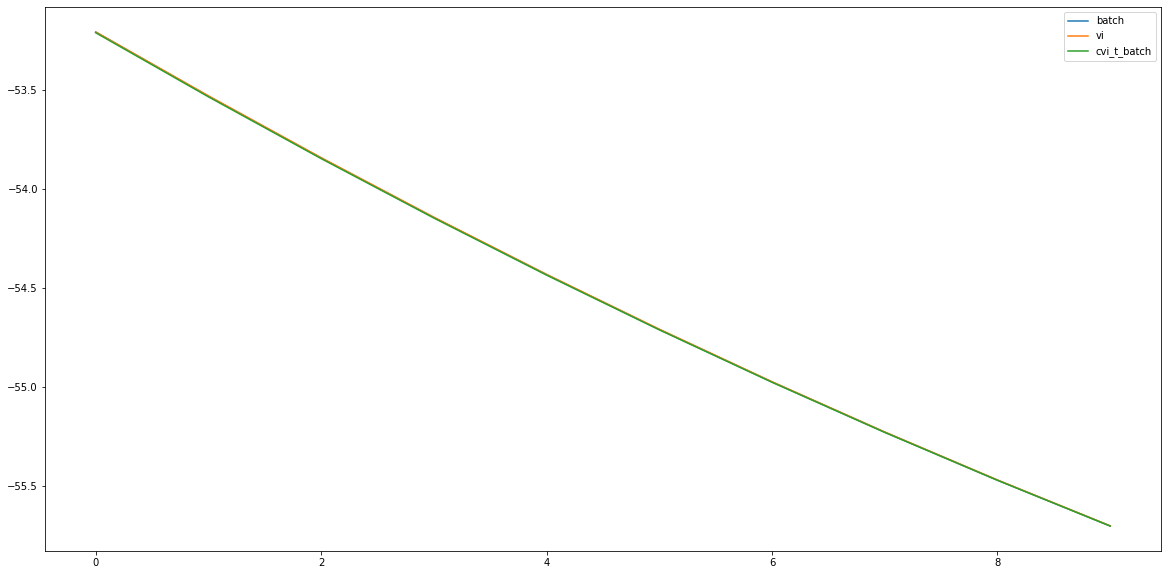

In [9]:
fig = plt.figure(figsize=(20, 10))
ax = plt.gca()
for m in res_time.keys():
    ax.plot(res_time[m]['lc'], label=m)
    print(f"{m}: {res_time[m]['lc'][1]}, {res_time[m]['lc'][-1]}")
plt.legend()

# Predictions

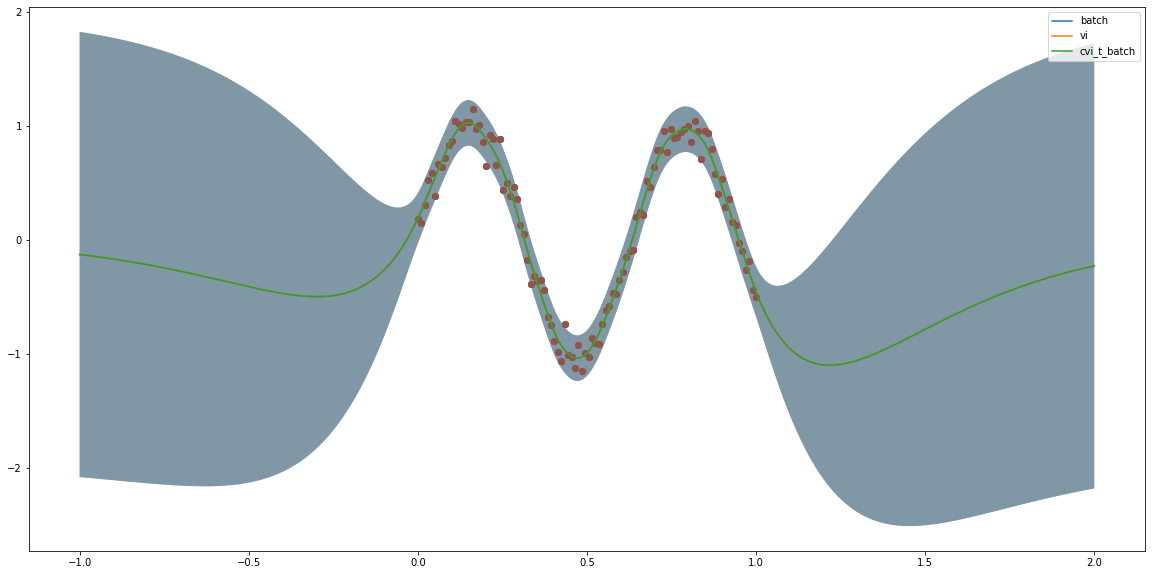

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

for m in res_time.keys():
    ax.fill_between(
        np.squeeze(XS), 
        np.squeeze(res_time[m]['pred_mu']-1.96*np.sqrt(res_time[m]['pred_var'])), 
        np.squeeze(res_time[m]['pred_mu']+1.96*np.sqrt(res_time[m]['pred_var'])),
        alpha=0.4
    )
    ax.plot(XS, res_time[m]['pred_mu'], label=m)
    ax.scatter(X, Y)
    

ax.legend()

In [ ]:
res_time.keys()